# 🚀 Bài Tập Khoa Học Dữ Liệu - Pipeline Hoàn Chỉnh

**1. Chuẩn hóa | 2. Tiền xử lý | 3. Model | 4. Đánh giá | 5. Giải thích**

---

## Bước 0: Import thư viện và tải dữ liệu


In [1]:
# Chạy 1 lần nếu chưa cài
# !pip install pandas numpy scikit-learn matplotlib seaborn pyodbc sqlalchemy scipy pandasql
print("✅ Sẵn sàng!")


✅ Sẵn sàng!


## Bước 1: Import thư viện 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pandasql as psql
import pyodbc

warnings.filterwarnings('ignore')
os.makedirs('results/figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Các thư viện Machine Learning cần thiết (Đã làm sạch)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


## Bước 2: Kết nối SQL & Load data

In [3]:
import pyodbc

def get_dataframe(query="SELECT * FROM Food_Delivery_Times"):
    SERVER   = "DESKTOP-D1HC55M"
    DATABASE = "abc"
    conn_str = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={SERVER};"
        f"DATABASE={DATABASE};"
        "Trusted_Connection=yes;"
    )
    conn = pyodbc.connect(conn_str)
    df   = pd.read_sql(query, conn)
    conn.close()
    return df

df = get_dataframe()

# Ép kiểu ngay sau khi load
df['Delivery_Time_min']      = pd.to_numeric(df['Delivery_Time_min'],      errors='coerce')
df['Distance_km']            = pd.to_numeric(df['Distance_km'],            errors='coerce')
df['Preparation_Time_min']   = pd.to_numeric(df['Preparation_Time_min'],   errors='coerce')
df['Courier_Experience_yrs'] = pd.to_numeric(df['Courier_Experience_yrs'], errors='coerce')

print("✅ Kết nối SQL Server thành công!")
print(f"Shape: {df.shape}")
df.head()  # hiện bảng đẹp trong notebook

✅ Kết nối SQL Server thành công!
Shape: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Bước 3: Thông tin dữ liệu

In [4]:
print("="*50)
print("THÔNG TIN DỮ LIỆU")
print("="*50)
print(f"Số dòng  : {df.shape[0]}")
print(f"Số cột   : {df.shape[1]}")
print(f"\nKiểu dữ liệu:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum().to_string())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.describe()     #mean: trung bình   std:độ lệch chuẩn


THÔNG TIN DỮ LIỆU
Số dòng  : 1000
Số cột   : 9

Kiểu dữ liệu:
Order_ID                      str
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

Missing values:
Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0

Duplicate rows: 0


,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.914394,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


## Bước 4: SQL Queries phân tích

In [5]:
import pandasql as psql

queries = {
    "Q1 - Thời tiết ảnh hưởng thế nào (Cơ bản)": """
        SELECT Weather, COUNT(*) AS tong_don,
               ROUND(AVG(Delivery_Time_min),2) AS tb_phut,
               ROUND(MIN(Delivery_Time_min),2) AS min_phut,
               ROUND(MAX(Delivery_Time_min),2) AS max_phut
        FROM df GROUP BY Weather ORDER BY tb_phut DESC
    """,
    
    "Q2 - Kinh nghiệm tài xế (Nâng cao - Đã vá lỗi ô trống NULL)": """
        SELECT CASE
                   WHEN Courier_Experience_yrs IS NULL THEN 'Chưa rõ thông tin (NULL)'
                   WHEN Courier_Experience_yrs < 1 THEN 'Mới (<1 năm)'
                   WHEN Courier_Experience_yrs < 3 THEN 'Trung bình (1-3 năm)'
                   ELSE 'Có kinh nghiệm (>3 năm)'
               END AS nhom_kn,
               COUNT(*) AS tong_don,
               ROUND(AVG(Delivery_Time_min),2) AS tb_phut
        FROM df
        GROUP BY CASE
                     WHEN Courier_Experience_yrs IS NULL THEN 'Chưa rõ thông tin (NULL)'
                     WHEN Courier_Experience_yrs < 1 THEN 'Mới (<1 năm)'
                     WHEN Courier_Experience_yrs < 3 THEN 'Trung bình (1-3 năm)'
                     ELSE 'Có kinh nghiệm (>3 năm)'
                 END
        ORDER BY tb_phut DESC
    """,
    
    "Q3 - Tắc đường + Thời tiết kết hợp (Chuyên sâu)": """
        SELECT Traffic_Level, Weather,
               COUNT(*) AS tong_don,
               ROUND(AVG(Delivery_Time_min),2) AS tb_phut
        FROM df GROUP BY Traffic_Level, Weather
        ORDER BY tb_phut DESC LIMIT 10
    """
}

# Động cơ vòng lặp vận hành an toàn bằng try-except
for title, q in queries.items():
    print(f"\n{'='*60}")
    print(f" 📊 {title.upper()}")
    print('='*60)
    try:
        result = psql.sqldf(q, locals())
        display(result)          
    except Exception as e:
        print(f"❌ Phát hiện lỗi cú pháp SQL: {e}")


 📊 Q1 - THỜI TIẾT ẢNH HƯỞNG THẾ NÀO (CƠ BẢN)


,Weather,tong_don,tb_phut,min_phut,max_phut
0,Snowy,97,67.11,24.0,115.0
1,Rainy,204,59.79,15.0,141.0
2,Foggy,103,59.47,25.0,116.0
3,Windy,96,55.46,16.0,122.0
4,,30,54.20,17.0,109.0
5,Clear,470,53.08,8.0,153.0



 📊 Q2 - KINH NGHIỆM TÀI XẾ (NÂNG CAO - ĐÃ VÁ LỖI Ô TRỐNG NULL)


,nhom_kn,tong_don,tb_phut
0,Mới (<1 năm),91,60.23
1,Trung bình (1-3 năm),206,57.55
2,Chưa rõ thông tin (NULL),30,56.37
3,Có kinh nghiệm (>3 năm),673,56.03



 📊 Q3 - TẮC ĐƯỜNG + THỜI TIẾT KẾT HỢP (CHUYÊN SÂU)


,Traffic_Level,Weather,tong_don,tb_phut
0,High,Rainy,44,77.05
1,Medium,Snowy,30,71.97
2,High,Snowy,20,70.90
3,,Snowy,3,69.33
4,High,Foggy,21,67.24
5,,Clear,17,65.24
6,High,,6,64.83
7,,Rainy,6,64.50
8,Medium,Foggy,34,64.09
9,High,Windy,23,63.48


## Bước 5: Biểu đồ EDA

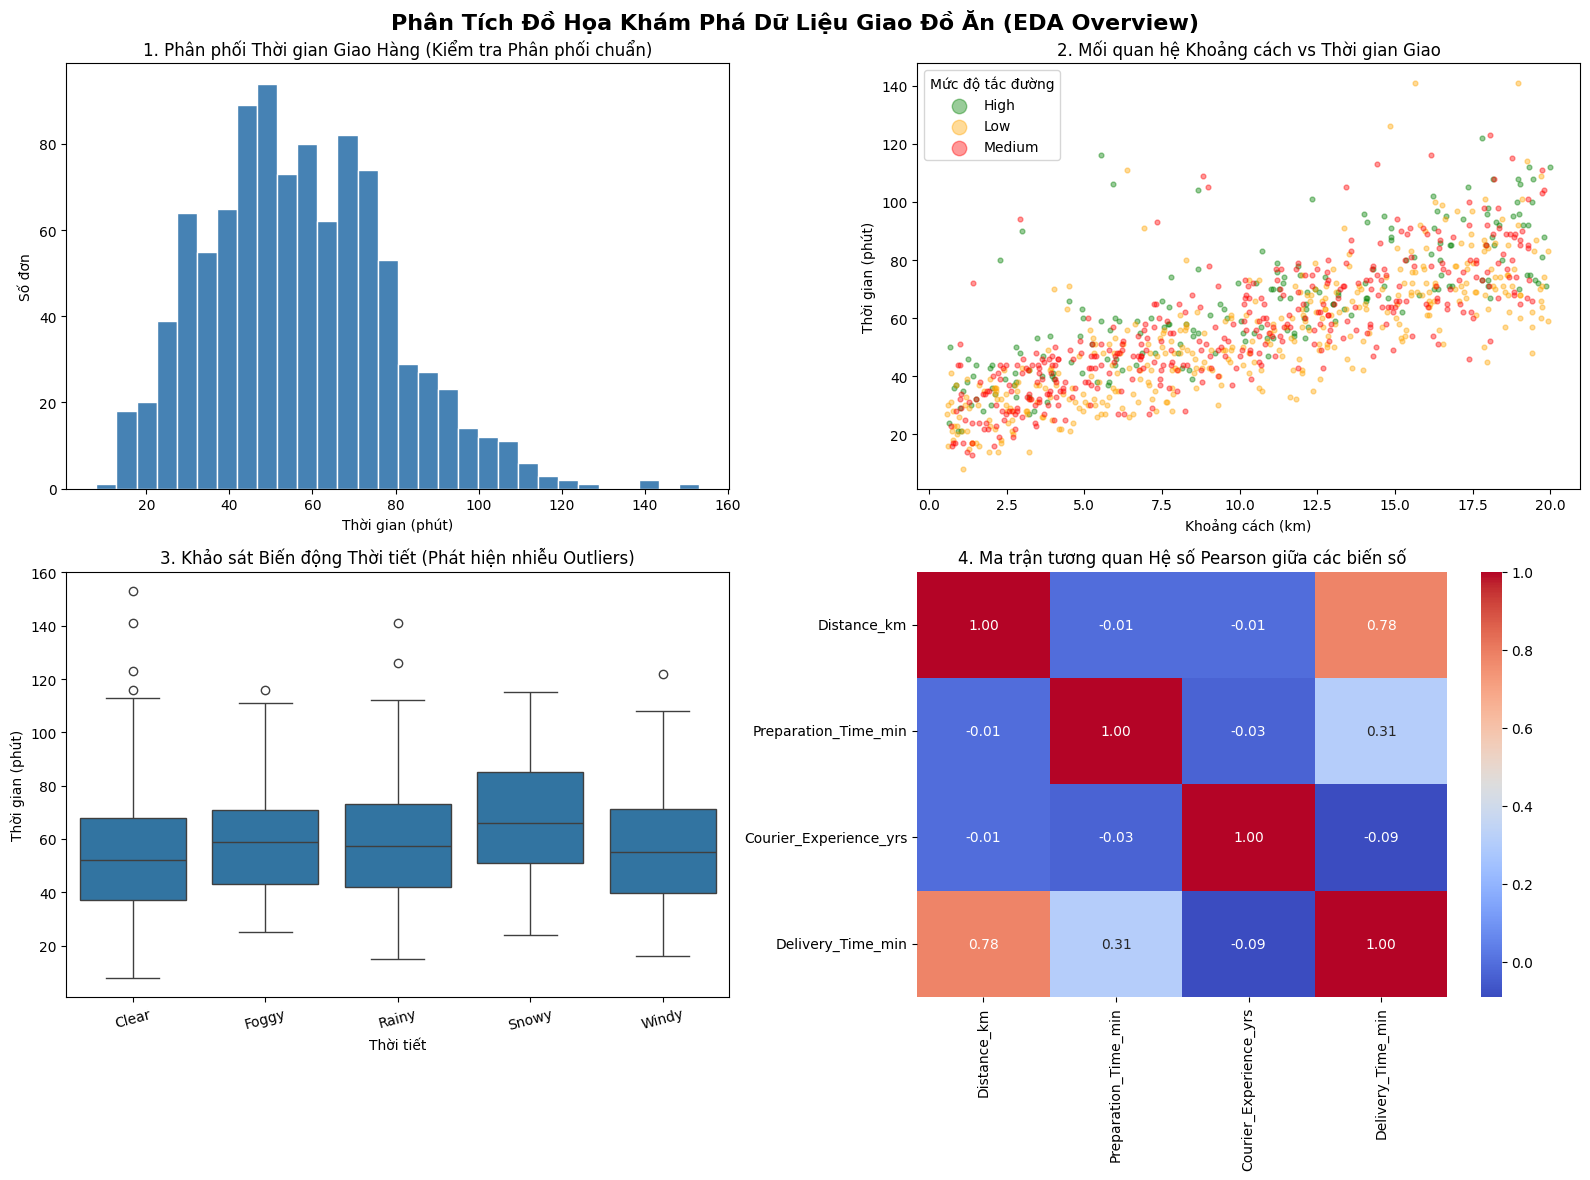

✅ Sơ đồ EDA rút gọn lưới 2x2 đã hoàn thành xuất sắc!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# CỤM 1: CẤU HÌNH KHUNG TRANH VÀ TIÊU ĐỀ
# Khởi tạo ma trận lưới 2 hàng, 2 cột (Tổng 4 hình chiến lược)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân Tích Đồ Họa Khám Phá Dữ Liệu Giao Đồ Ăn (EDA Overview)', fontsize=16, fontweight='bold')

# --- CHUẨN BỊ DỮ LIỆU SẠCH CHO ĐỒ HỌA ---
# Do ảnh SQL Q3 cho thấy Traffic_Level và Weather dính lỗi ô trống chữ '',
# ta tạo một bản sao df_plot và ép kiểu chữ, sau đó thay ô trống bằng NaN để lọc bỏ.
df_plot = df.copy()
df_plot['Traffic_Level'] = df_plot['Traffic_Level'].astype(str).replace('', np.nan)
df_plot['Weather'] = df_plot['Weather'].astype(str).replace('', np.nan)

# CỤM 2: TIẾN HÀNH VẼ 4 SƠ ĐỒ CHIẾN LƯỢC

# Ô số 1: Histogram (Hàng 0, Cột 0) -> Kiểm tra phân phối chuẩn
axes[0,0].hist(df['Delivery_Time_min'].dropna(), bins=30,
               color='steelblue', edgecolor='white')
axes[0,0].set_title('1. Phân phối Thời gian Giao Hàng (Kiểm tra Phân phối chuẩn)')
axes[0,0].set_xlabel('Thời gian (phút)'); axes[0,0].set_ylabel('Số đơn')

# Ô số 2: Scatterplot (Hàng 0, Cột 1) -> Đánh giá tính tuyến tính & Minh họa kịch bản kẹt xe
color_list = ['green','orange','red','blue','purple']
# Lọc bỏ các dòng dính ô trống trong Traffic_Level để chia màu chuẩn
df_scatter = df_plot.dropna(subset=['Traffic_Level']).copy()
# Ép kiểu số an toàn cho khoảng cách của riêng nhóm này
df_scatter['Distance_km'] = pd.to_numeric(df_scatter['Distance_km'], errors='coerce')

color_map  = {v: color_list[i % len(color_list)]
              for i, v in enumerate(sorted(df_scatter['Traffic_Level'].unique()))}
for tval, grp in df_scatter.groupby('Traffic_Level'):
    axes[0,1].scatter(grp['Distance_km'], grp['Delivery_Time_min'],
                      label=tval, alpha=0.4, s=12, color=color_map.get(tval,'blue'))
axes[0,1].set_title('2. Mối quan hệ Khoảng cách vs Thời gian Giao')
axes[0,1].set_xlabel('Khoảng cách (km)'); axes[0,1].set_ylabel('Thời gian (phút)')
axes[0,1].legend(title='Mức độ tắc đường', markerscale=3)

# Ô số 3: Boxplot theo Weather (Hàng 1, Cột 0) -> Phát hiện Outliers ngày mưa bão
# Dữ liệu được lọc bỏ các ô trống trong cột Weather
df_boxplot = df_plot.dropna(subset=['Weather']).copy()

# Vẽ biểu đồ hộp bằng thư viện Seaborn để tự động gom nhóm thời tiết
sns.boxplot(data=df_boxplot, x='Weather', y='Delivery_Time_min', 
            order=sorted(df_boxplot['Weather'].unique()), ax=axes[1,0])
axes[1,0].set_title('3. Khảo sát Biến động Thời tiết (Phát hiện nhiễu Outliers)')
axes[1,0].set_ylabel('Thời gian (phút)'); axes[1,0].set_xlabel('Thời tiết')
axes[1,0].tick_params(axis='x', rotation=15) # Xoay chữ nhãn thời tiết cho dễ đọc

# Ô số 4: Heatmap (Hàng 1, Cột 1) -> Đo lường tương quan, chặn lỗi đa cộng tuyến
# Lọc ra danh sách các cột mang định dạng số để tính toán toán học
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Vẽ bản đồ nhiệt chuyển màu từ xanh (nghịch) sang đỏ (thuận)
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('4. Ma trận tương quan Hệ số Pearson giữa các biến số')

# CỤM 3: ĐỒNG GÓI, CĂN CHỈNH THẨM MỸ VÀ XUẤT FILE ẢNH
plt.tight_layout()
# Lưu file ảnh vật lý chất lượng cao dpi=150, tự động cắt viền trắng thừa 'tight'
plt.savefig('results/figures/EDA_overview_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sơ đồ EDA rút gọn lưới 2x2 đã hoàn thành xuất sắc!")

## Bước 6: Tiền xử lý

In [7]:
df_model = df.copy()
if 'Order_ID' in df_model.columns:
    df_model.drop(columns=['Order_ID'], inplace=True)

# Ép kiểu
num_cols_raw = ['Distance_km','Preparation_Time_min',
                'Courier_Experience_yrs','Delivery_Time_min']
cat_cols_raw = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']

for col in num_cols_raw:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
for col in cat_cols_raw:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.strip()

# Fill missing
for col in df_model.select_dtypes(include=[np.number]).columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

# Encode
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Tách X, y
TARGET   = 'Delivery_Time_min'
X        = df_model.drop(columns=[TARGET]).values.astype(np.float64)
y        = df_model[TARGET].values.astype(np.float64)

# Xóa NaN còn sót
if np.isnan(X).sum() > 0 or np.isnan(y).sum() > 0:
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    X, y = X[mask], y[mask]

# Scale & split
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

np.save('data/X_train.npy', X_train); np.save('data/X_test.npy',  X_test)
np.save('data/y_train.npy', y_train); np.save('data/y_test.npy',  y_test)

print(f"✅ Tiền xử lý hoàn thành!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"NaN trong X_train: {np.isnan(X_train).sum()}")


✅ Tiền xử lý hoàn thành!
X_train: (776, 7) | X_test: (194, 7)
NaN trong X_train: 0


## Bước 7: Xây dựng mô hình

In [8]:
## Bước 7: Linear, Random Forest & Gradient Boosting Regression
results = []

# ==========================================
# 1. Linear Regression (Mô hình gốc)
# ==========================================
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

results.append({
    'Mo_hinh': 'Linear Regression',
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
})

# ==========================================
# 2. Random Forest Regressor
# ==========================================
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

results.append({
    'Mo_hinh': 'Random Forest',
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
})

# ==========================================
# 3. Gradient Boosting Regressor
# ==========================================
model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

results.append({
    'Mo_hinh': 'Gradient Boosting',
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'MAE': mean_absolute_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb)
})

# Hiển thị bảng kết quả chung
df_results = pd.DataFrame(results)
print("==================================================")
print("BẢNG ĐÁNH GIÁ 3 MÔ HÌNH")
print("==================================================")
display(df_results)

BẢNG ĐÁNH GIÁ 3 MÔ HÌNH


,Mo_hinh,RMSE,MAE,R2
0,Linear Regression,10.568722,7.097461,0.778315
1,Random Forest,11.015844,7.605928,0.759161
2,Gradient Boosting,10.942214,7.196203,0.762370


## Bước 8: Tổng kết và so sánh kết quả

In [9]:
## Bước 8: TỔNG KẾT DỰ ÁN
print("="*65)
print("         TỔNG KẾT KẾT QUẢ TOÀN BỘ DỰ ÁN")
print("="*65)

# In thông tin dữ liệu
print(f"\n📌 Dữ liệu huấn luyện: {X_train.shape[0]} dòng | Dữ liệu kiểm thử: {X_test.shape[0]} dòng")

# Sắp xếp để tìm mô hình tốt nhất
print("\n📌 Bảng Xếp hạng Mô hình (Tốt nhất xếp trên cùng):")
df_sorted = df_results.sort_values(by='RMSE').reset_index(drop=True)
display(df_sorted)

# Lấy mô hình có sai số RMSE thấp nhất
best_all = df_sorted.loc[0]

print(f"\n🏆 Mô hình tốt nhất: {best_all['Mo_hinh']}")
print(f"   RMSE = {best_all['RMSE']:.4f}")
print(f"   MAE  = {best_all['MAE']:.4f}")
print(f"   R²   = {best_all['R2']:.4f} (Giải thích được {best_all['R2']*100:.1f}% sự biến động của dữ liệu)")

print("\n✅ SẴN SÀNG BÁO CÁO!")

         TỔNG KẾT KẾT QUẢ TOÀN BỘ DỰ ÁN

📌 Dữ liệu huấn luyện: 776 dòng | Dữ liệu kiểm thử: 194 dòng

📌 Bảng Xếp hạng Mô hình (Tốt nhất xếp trên cùng):


,Mo_hinh,RMSE,MAE,R2
0,Linear Regression,10.568722,7.097461,0.778315
1,Gradient Boosting,10.942214,7.196203,0.762370
2,Random Forest,11.015844,7.605928,0.759161



🏆 Mô hình tốt nhất: Linear Regression
   RMSE = 10.5687
   MAE  = 7.0975
   R²   = 0.7783 (Giải thích được 77.8% sự biến động của dữ liệu)

✅ SẴN SÀNG BÁO CÁO!
